In [14]:
import pandas as pd

tweets = pd.read_csv('tweets.csv', encoding = "utf-8")

tweets.head()

,tweet,topic
0,@sssdddnnn333 @MohammedAlDeaye حارس حتى عنده ض...,Sports
1,RT @fahadaljehani: الكثير من المتعة كانت حاضره...,Sports
2,RT @aboaljorya: @AhmedAllshehri عذيب 👀\nالسعر ...,Business
3,RT @salem_d29: الحمدلله ، شعوري لا يوصف ، ولن ...,Sports
4,أبل أبدعت بهذي الميزة الأمر مستحيل ومجرد خيال ...,Technology


In [15]:
print('Data size:', tweets.shape)

Data size: (26747, 2)


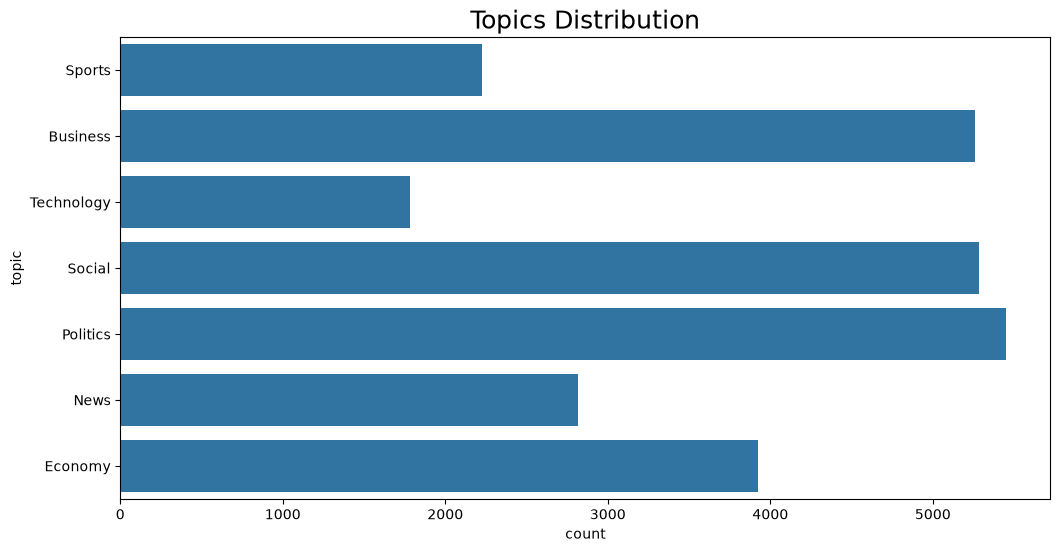

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.countplot(data=tweets, y='topic')
plt.title('Topics Distribution', fontsize=18)

plt.show()

In [17]:
import string
import re
import nltk

nltk.download('punkt')

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from snowballstemmer import stemmer

def remove_chars(text, del_chars):
    for char in del_chars:
        text = text.replace(char, "")
    return text

def remove_repeating_char(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

def clean_tweet(tweet):
      
    emoj = re.compile("["
            u"\U0001F600-\U0001F64F"  
            u"\U0001F300-\U0001F5FF"  
            u"\U0001F680-\U0001F6FF"  
            u"\U0001F1E0-\U0001F1FF" 
            u"\U00002500-\U00002BEF"  
            u"\U00002702-\U000027B0"
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            u"\U0001f926-\U0001f937"
            u"\U00010000-\U0010ffff"
            u"\u2640-\u2642" 
            u"\u2600-\u2B55"
            u"\u200d"
            u"\u23cf"
            u"\u23e9"
            u"\u231a"
            u"\ufe0f"  
            u"\u3030"
            u"\u2066"
                        "]+", re.UNICODE)
    
    tweet =  re.sub(emoj, '', tweet)

    
    tweet = re.sub("@[^\s]+","",tweet)
    
    tweet = re.sub("RT","",tweet)
    
    tweet = re.sub(r"(?:\|http?\://|https?\://|www)\S+", "", tweet)
    
    tweet = re.sub(r'[0-9]+', '', tweet)  
    
    tweet = remove_chars(tweet, "٠١٢٣٤٥٦٧٨٩")
 
    
    arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
    
    english_punctuations = string.punctuation
    
    punctuations_list = arabic_punctuations + english_punctuations
    tweet = remove_chars(tweet, punctuations_list)
     
    tweet = remove_repeating_char(tweet)
    
    tweet = tweet.replace('\n', ' ')  
      
    tweet = tweet.strip(' ')  
    return tweet

<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
C:\Users\aziz1\AppData\Local\Temp\ipykernel_32404\3850146389.py:48: SyntaxWarning: invalid escape sequence '\s'
  tweet = re.sub("@[^\s]+","",tweet)
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aziz1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aziz1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
def tokenizingText(text):
    tokens_list = word_tokenize(text)
    return tokens_list

def filteringText(tokens_list):
    
    listStopwords = stopwords.words('arabic')
    filtered = []
    for txt in tokens_list:
        if txt not in listStopwords:
            filtered.append(txt)
    return filtered

def stemmingText(tokens_list): 
    
    ar_stemmer = stemmer("arabic")
    tokens_list = [ar_stemmer.stemWord(word) for word in tokens_list]
    return tokens_list
    
def toSentence(words_list):  
    sentence = ' '.join(word for word in words_list)
    return sentence

In [19]:
def process_tweet(tweet):
    
    tweet=clean_tweet(tweet)
    
    tokens_list=tokenizingText(tweet)
    
    tokens_list=filteringText(tokens_list)
    
    tokens_list=stemmingText(tokens_list)
    return tokens_list

In [20]:
text= "أنا أحب الذهاب إلى الحديقة 🌝، كل يوم 9 صباحاً، مع رفاقي هؤلاء! @toto  "

processed_tweet= process_tweet(text)
print(processed_tweet)

['احب', 'ذهاب', 'حديق', 'يوم', 'صباح', 'رفاق']


In [21]:
tweets['tweet'] = tweets['tweet'].apply(process_tweet)

tweets

,tweet,topic
0,"[حارس, عند, ضعف, نظر, مدر, يحرص, عموم, حال, حا...",Sports
1,"[كثير, متع, كان, حاضر, ملعب, قيم, الفن, عاليه,...",Sports
2,"[عذيب, سعر, حال]",Business
3,"[حمدلله, شعور, يوصف, ولن, انسي, فضل, جمهور, هل...",Sports
4,"[ابل, ابدع, بهذ, ميز, امر, مستحيل, مجرد, خيال,...",Technology
...,...,...
26742,"[خير, سحب, مبلغ, الاف, ولم, تخرج, صراف, طريق, ...",Business
26743,"[صرف, ادو, ياخذ, اسبوع, لاسبوع, والادو, باق, ا...",Business
26744,"[جيت, قدم, لاغ, يوم, رقع, اسعار, تطبيق, مشكل, ...",Business
26745,"[حال, توف, مريض, مستشفي, حق, مطالب, ماليه, نرج...",Business


In [22]:
from imblearn.over_sampling import RandomOverSampler

oversample = RandomOverSampler()

tweets, Y = oversample.fit_resample(tweets, tweets.topic)

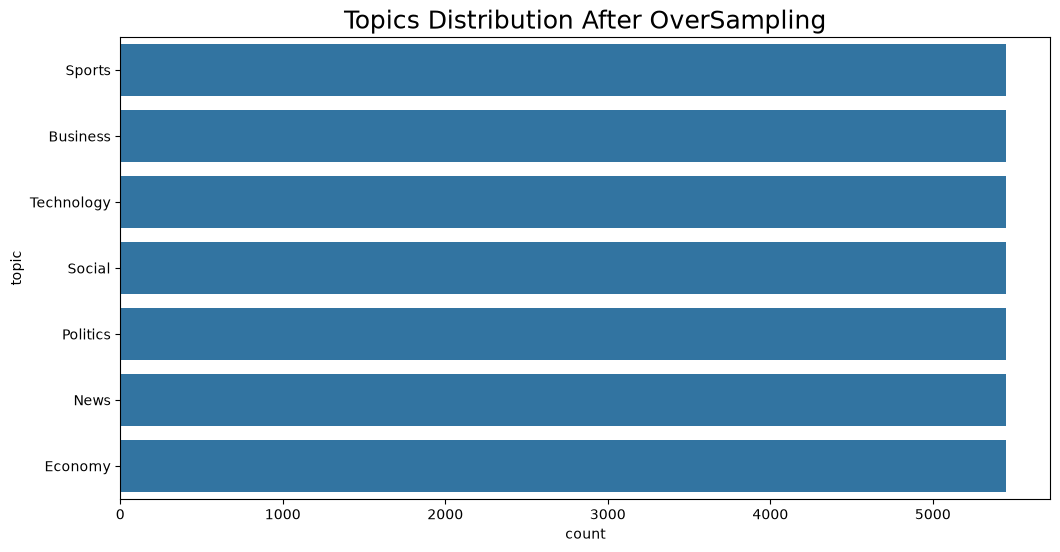

In [23]:
plt.figure(figsize=(12, 6))

sns.countplot(data=tweets, y='topic');
plt.title('Topics Distribution After OverSampling', fontsize=18)

plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

le_topics = LabelEncoder()
tweets['topic'] = tweets[['topic']].apply(le_topics.fit_transform)

classes = le_topics.classes_

n_classes = len(classes)
print("No. of classes:", n_classes)
print("Classes:", classes)
print("Coding: ", le_topics.transform(classes))

No. of classes: 7
Classes: ['Business' 'Economy' 'News' 'Politics' 'Social' 'Sports' 'Technology']
Coding:  [0 1 2 3 4 5 6]


In [25]:
sentences = tweets['tweet'].apply(toSentence)

sentences

0        حارس عند ضعف نظر مدر يحرص عموم حال حال لاعب هل...
1        كثير متع كان حاضر ملعب قيم الفن عاليه سالمالدو...
2                                             عذيب سعر حال
3        حمدلله شعور يوصف ولن انسي فضل جمهور هلال عل شخ...
4        ابل ابدع بهذ ميز امر مستحيل مجرد خيال سنة ايبا...
                               ...                        
38145    فايروس خطير جدا استهدف مستخدم نظام اندرويد قاد...
38146    استفد شيء نبي يرجع اول احدث تغريد دون تطلع تغر...
38147                          ازرار اضاف مسابق مستقبلTECH
38148         يوجد ازرار اضاف مجموع ازرار مسابق مستقبلTECH
38149                           متجر جوجل عبار حراج تطبيقا
Name: tweet, Length: 38150, dtype: str

In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

# 1. Initialize and fit
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

# 2. Get the total number of unique words
num_words = len(tokenizer.word_index)
print("Number of words:", num_words)

Number of words: 21984


In [27]:
max_words = 10000

tokenizer = Tokenizer(num_words=max_words )

tokenizer.fit_on_texts(sentences)

X = tokenizer.texts_to_sequences(sentences)

In [28]:
print(X[0])
print(X[1])

[2939, 48, 1637, 230, 1638, 6304, 2940, 165, 165, 727, 2, 3885, 4502, 165]
[285, 1800, 243, 2799, 2477, 179, 322, 4925, 4926, 489, 1761, 4147, 151]


In [29]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 50

X = pad_sequences(X, maxlen=max_len)
print(X[0])
print(X[1])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0 2939   48 1637  230 1638 6304
 2940  165  165  727    2 3885 4502  165]
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0  285 1800  243 2799 2477
  179  322 4925 4926  489 1761 4147  151]


In [30]:
tweets

,tweet,topic
0,"[حارس, عند, ضعف, نظر, مدر, يحرص, عموم, حال, حا...",5
1,"[كثير, متع, كان, حاضر, ملعب, قيم, الفن, عاليه,...",5
2,"[عذيب, سعر, حال]",0
3,"[حمدلله, شعور, يوصف, ولن, انسي, فضل, جمهور, هل...",5
4,"[ابل, ابدع, بهذ, ميز, امر, مستحيل, مجرد, خيال,...",6
...,...,...
38145,"[فايروس, خطير, جدا, استهدف, مستخدم, نظام, اندر...",6
38146,"[استفد, شيء, نبي, يرجع, اول, احدث, تغريد, دون,...",6
38147,"[ازرار, اضاف, مسابق, مستقبلTECH]",6
38148,"[يوجد, ازرار, اضاف, مجموع, ازرار, مسابق, مستقب...",6


In [31]:
y = tweets['topic']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

In [33]:
from keras.models import Sequential

from keras.layers import Embedding, Dense, LSTM

embed_dim = 32
hidden_unit = 16
dropout_rate = 0.2

model = Sequential()

model.add(Embedding(input_dim = max_words, output_dim = embed_dim, input_length = max_len))

model.add(LSTM(units = hidden_unit, dropout=dropout_rate))

model.add(Dense(units = len(classes), activation = 'softmax'))

c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\01_Local_Jupyter_Notebooks\03_Deep_Learning\churn_env\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [34]:
model.compile(loss = 'sparse_categorical_crossentropy', 
              optimizer = 'adam', metrics = ['accuracy'])

In [35]:
history = model.fit(X_train, y_train,
                             epochs=10, batch_size=32,
                             validation_data=(X_test, y_test))

Epoch 1/10
895/895 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.7481 - loss: 0.8341 - val_accuracy: 0.8788 - val_loss: 0.4220
Epoch 2/10
895/895 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9137 - loss: 0.2962 - val_accuracy: 0.9090 - val_loss: 0.3162
Epoch 3/10
895/895 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9479 - loss: 0.1787 - val_accuracy: 0.9159 - val_loss: 0.3097
Epoch 4/10
895/895 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9649 - loss: 0.1231 - val_accuracy: 0.9164 - val_loss: 0.3180
Epoch 5/10
895/895 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9740 - loss: 0.0931 - val_accuracy: 0.9171 - val_loss: 0.3373
Epoch 6/10
895/895 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9778 - loss: 0.0773 - val_accuracy: 0.9199 - val_loss: 0.3428
Epoch 7/10
895/895 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9820 - loss: 0.0613 - val_accuracy: 0.9185 - val_loss: 0.3530
Epoch 8/10
895/895 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9851 - loss: 0.0512 - 

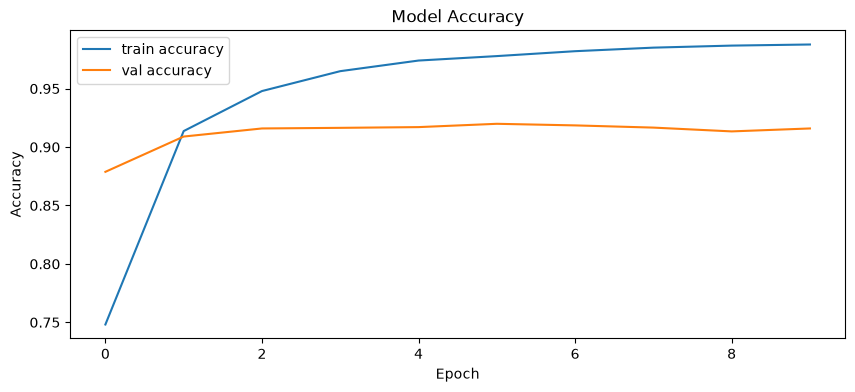

In [36]:
fig, ax = plt.subplots(figsize = (10, 4))

ax.plot(history.history['accuracy'], label = 'train accuracy')
ax.plot(history.history['val_accuracy'], label = 'val accuracy')

ax.set_title('Model Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend(loc = 'upper left')

plt.show()

In [37]:
model.save('perosn_classification_model.keras')

import pickle
tokenizer_path = 'perosn_classification_tokenizer'
with open(tokenizer_path, 'wb') as file:
    pickle.dump(tokenizer, file)

In [38]:
import numpy as np

def classify_tweet(tweet, model, tokenizer, max_len=50):
    
    seq = tokenizer.texts_to_sequences([tweet])
    
    pseq = pad_sequences(seq, maxlen=max_len)
    
    predections = model.predict(pseq)
    
    pred=np.argmax(predections)
    return pred

In [39]:
from keras.models import load_model
import pickle
classes= ['Business', 'Economy', 'News', 'Politics', 'Social', 'Sports', 'Technology']

def classify_person(person_name,model_path, tokenizer_path, person_path):
    
    model = load_model(model_path)
    
    with open(tokenizer_path, 'rb') as file:
        tokenizer = pickle.load(file)
    
    df = pd.read_csv(person_path)
    
    classes_count=dict()
    
    for i in range(len(classes)):
        key=classes[i]
        classes_count[key]=0

    for _, row in df.iterrows():
        tweet=row['tweet']
        
        processed_tweet=process_tweet(tweet)
        
        code= classify_tweet(processed_tweet, model, tokenizer)
        
        topic=classes[code]
        
        classes_count[topic]=classes_count[topic]+1
 

    x = classes_count.keys()
    y = classes_count.values()

    import matplotlib.pyplot as plt
    # pie
    plt.figure(figsize=(5,5))
    plt.title(person_name, fontdict = {'fontsize':20})
    plt.pie(y, labels = x,autopct='%1.1f%%')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━

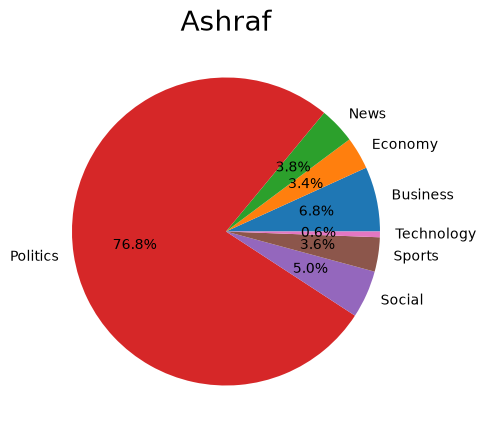

In [40]:
classify_person("Ashraf", 'perosn_classification_model.keras',
                'perosn_classification_tokenizer','ashraf.csv')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━

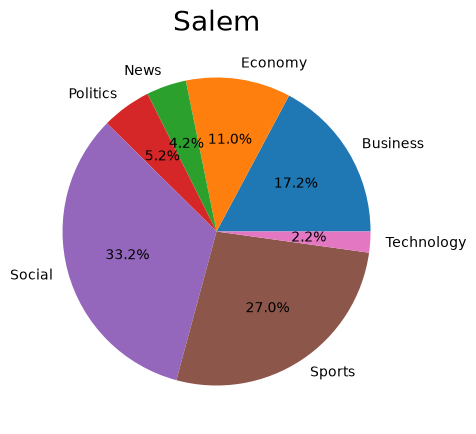

In [41]:
classify_person("Salem",'perosn_classification_model.keras',
                'perosn_classification_tokenizer','salem.csv')